In [7]:
import pandas as pd

# 读取 CSV 文件
df = pd.read_csv("dataset.csv")

# 创建均价列
df['均价'] = df['价格'] / df['总面积']

# 查看数据
print(df.head())      # 查看前5行（Python 默认是5行）
print("\n数据类型：")
print(df.dtypes)      # 查看数据结构
print("\n统计摘要：")
print(df.describe(include='all'))  # 查看统计摘要

# 如果需要更详细的统计信息（类似 R 的 summary）
print("\n详细统计摘要：")
print(df.info())      # 查看数据框信息
print("\n")
print(df.describe())  # 数值列的统计信息

                               标题  居室数  厅堂数  卫生间数  总面积    建造年份  居民楼总层数  \
0  扫码唻电联系房东，真的急疯了，这价格还卖不掉房东说要刀了我！    2    1     1   17  2018.0    11.0   
1             正南 3室2厅 万科海上传奇(一二期)    3    2     1   97  2014.0    22.0   
2                虹浦新城南区 通透三房 预约看房    3    1     1   93  2007.0    11.0   
3     18号地铁口！进才  ，南北通透沉香苑，房东置换急 售    2    2     1   90  2013.0    11.0   
4  市区独栋别墅！送400平大花园！自带私家游泳池！位置不靠马路    5    3     3  300  2010.0     2.0   

     小区户数  小区绿化率  物业费用  ...           小区      南     南北   近地铁   车位充足   户型方正  \
0    50.0   30.0  0.40  ...      虹中路2弄小区  False   True  True   True  False   
1  2336.0   45.0  3.00  ...  万科海上传奇(一二期)   True  False  True  False  False   
2  1731.0   30.0  1.25  ...     虹浦新城(南区)  False   True  True  False  False   
3   971.0   35.0  1.20  ...       沉香苑一街坊  False   True  True  False   True   
4    68.0   43.0  5.50  ...         虹梅别墅   True  False  True   True  False   

    多人关注    有电梯    价格         均价  
0  False  False    50   2.941176  
1  False  False 

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'PingFang SC']
plt.rcParams['axes.unicode_minus'] = False

def plot_boxplot_single(df, var):
    """
    参数:
        df: 已包含'均价'列的数据框
        var: 单个分类变量名，如 '装修' 或 '居室数'
    
    返回:
        None（直接显示图形）
    """
    
    # 设置绘图风格
    sns.set_style("whitegrid")
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 绘制箱线图
    sns.boxplot(data=df, x=var, y='均价', palette='Set2', linewidth=1.5)
    
    # 添加均值点
    means = df.groupby(var)['均价'].mean().reset_index()
    sns.scatterplot(data=means, x=var, y='均价', 
                   color='red', s=100, marker='D', 
                   label='均值', zorder=5)
    
    # 设置标题和标签
    plt.title(f'均价按 {var} 分组', fontsize=14, fontweight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel('均价（元/平米）', fontsize=12)
    
    # 旋转 x 轴标签
    plt.xticks(rotation=45, ha='right')
    
    # 添加图例和网格
    plt.legend()
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # 调整布局并显示
    plt.tight_layout()
    plt.show()
    
    # 打印分组统计
    print(f"\n【{var} 箱线图统计】")
    print(df.groupby(var)['均价'].agg(['count', 'mean', 'median', 'std']).round(2))
    print("\n" + "-" * 50 + "\n")


/var/folders/hj/7nl0f8151cg3pchhj170sdsc0000gn/T/ipykernel_51277/230395255.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=var, y='均价', palette='Set2', linewidth=1.5)
/var/folders/hj/7nl0f8151cg3pchhj170sdsc0000gn/T/ipykernel_51277/230395255.py:46: UserWarning: Glyph 23460 (\N{CJK UNIFIED IDEOGRAPH-5BA4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hj/7nl0f8151cg3pchhj170sdsc0000gn/T/ipykernel_51277/230395255.py:46: UserWarning: Glyph 21450 (\N{CJK UNIFIED IDEOGRAPH-53CA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hj/7nl0f8151cg3pchhj170sdsc0000gn/T/ipykernel_51277/230395255.py:46: UserWarning: Glyph 20197 (\N{CJK UNIFIED IDEOGRAPH-4EE5}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/hj/7nl0f8151cg3pchhj170sdsc0000gn/T/ipykernel_51277/230395255.py:46: UserWarning: Glyp

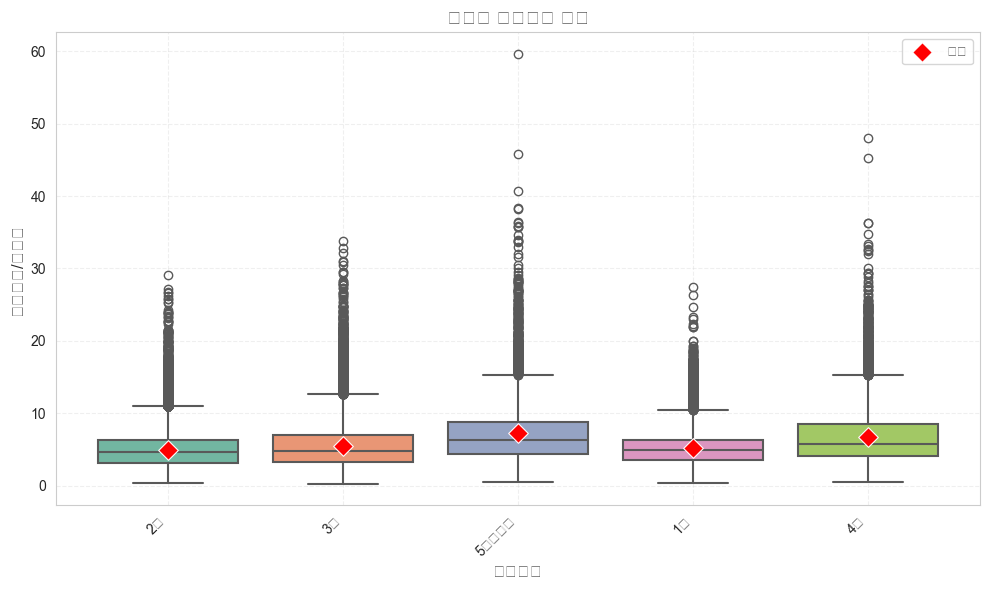


【居室分组 箱线图统计】
       count  mean  median   std
居室分组                            
1室     26562  5.24    4.88  2.49
2室     80884  4.96    4.60  2.52
3室     49656  5.47    4.84  3.06
4室     12226  6.74    5.81  3.99
5室及以上   5799  7.33    6.32  4.69

--------------------------------------------------



In [10]:
df = df[df['居室数'] != 0].copy()
df['居室分组'] = df['居室数'].apply(lambda x: '5室及以上' if x > 4 else str(x) + '室')
plot_boxplot_single(df, '居室分组')

In [6]:
# 使用清华镜像源安装
!pip install seaborn -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple

[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
